# Analyze AIT Log Data Set V2.0

In [154]:
import pandas as pd
import hashlib

## Fox Netflows

In [169]:
fox_netflows_path = "../data/raw/aitv2/fox_netflows/tcp_complete.csv"
df_netflows = pd.read_csv(fox_netflows_path)

In [170]:
df_netflows_labels_counts = df_netflows["label"].value_counts()
print(df_netflows_labels_counts)

label
proxy                                64434
HTTPS                                34918
browsing/update                      27876
benign_share                         23074
HTTP(S) DMZ                          18427
dirb_scan                             8256
mail                                  2942
HTTP(S) intra                         2371
HTTP                                   944
monitoring                             606
service_scan                           262
host_discover_dmz                      136
wpscan                                 128
online_cracking                         60
host_discover_local                     30
SSH                                     19
DNS                                      7
update/command on unassigned port        2
upload_rce_shell                         2
check_netstat_t                          2
check_user_id                            2
check_network_config                     2
check_ps_a                               2
check

In [171]:
all_labels = df_netflows["label"].unique()
print(all_labels)

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'HTTPS' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP(S) intra' 'HTTP'
 'host_discover_local' 'wpscan' 'dirb_scan' 'upload_rce_shell'
 'check_user_id' 'check_netstat_t' 'read_resolv' 'check_network_config'
 'check_ps_a' 'check_release' 'read_group' 'read_passwd' 'check_date'
 'list_web_dir' 'check_wp_config' 'dump_wp_users' 'read_profile'
 'dns_brute_force_start' 'HTTP(S) DMZ']


## Concatenate all sensor files

In [172]:
dataset = "aitv2"
scenario = "fox"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"

In [173]:
sensor_hosts = ["cloud_share", "inet_firewall", "internal_share", "intranet_server", "mail", "vpn", "webserver"]

In [174]:
all_sensor_files = []

for sensor_host in sensor_hosts:
    df = pd.read_csv(
        f"{data_dir}/{sensor_host}_labeled.csv"
    )
    df["sensor_host"] = sensor_host
    all_sensor_files.append(df)

df_all_sensors = pd.concat(all_sensor_files, ignore_index=True)
df_all_sensors = df_all_sensors.sort_values("start_time").reset_index(drop=True)
df_all_sensors.to_csv(f"{data_dir}/all_sensors_labeled.csv", index=False)

print("Combined dataset shape:", df_all_sensors.shape)
df_all_sensors.head(10)

Combined dataset shape: (545340, 25)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host
0,f0,1.642159e+09,1.642159e+09,61.748287,172.17.128.63,37828,172.17.131.81,22,tcp,-,...,0,ADdaFf,56,5836,65,6176,-,6,benign,mail
1,f0,1.642159e+09,1.642159e+09,0.004262,192.168.128.4,62003,192.168.255.254,53,udp,dns,...,0,Dd,1,276,1,292,-,17,benign,inet_firewall
2,f21513,1.642159e+09,1.642661e+09,501976.017070,10.35.35.206,37150,10.35.35.204,5044,tcp,-,...,0,DadATT,151060,140062920,89624,4852876,-,6,benign,intranet_server
3,f41508,1.642159e+09,1.642661e+09,501976.012480,10.35.33.111,39596,10.35.35.204,5044,tcp,-,...,0,DadATTt,137961,133145969,80513,4340882,-,6,benign,internal_share
4,f7,1.642159e+09,1.642159e+09,94.711953,10.35.33.111,39594,10.35.35.204,5044,tcp,-,...,0,AaDdr,15,3669,12,654,-,6,benign,internal_share
5,f0,1.642159e+09,1.642159e+09,0.003021,10.35.33.111,42855,10.35.32.1,53,udp,dns,...,0,Dd,1,276,1,292,-,17,benign,internal_share
6,f1,1.642159e+09,1.642159e+09,0.001896,192.168.128.4,7293,192.168.255.254,53,udp,dns,...,0,Dd,1,276,1,292,-,17,benign,inet_firewall
7,f1,1.642159e+09,1.642159e+09,94.713316,10.35.35.206,37148,10.35.35.204,5044,tcp,-,...,0,AaDdr,16,4203,12,654,-,6,benign,intranet_server
8,f1,1.642159e+09,1.642159e+09,0.004448,10.35.33.111,51010,10.35.32.1,53,udp,dns,...,0,Dd,1,276,1,292,-,17,benign,internal_share
9,f2,1.642159e+09,1.642159e+09,0.003177,192.168.128.4,63664,192.168.255.254,53,udp,dns,...,0,Dd,1,276,1,292,-,17,benign,inet_firewall


In [175]:
def compute_hash(df: pd.DataFrame, columns: list) -> pd.Series:
    return (
        df[columns]
        .astype(str)
        .agg("|".join, axis=1)
        .apply(lambda x: hashlib.md5(x.encode()).hexdigest())
    )

In [176]:
# Round start_time and end_time to 1 decimal place for matching
df_all_sensors["start_time_match"] = df_all_sensors["start_time"].round(1)
df_all_sensors["end_time_match"] = df_all_sensors["end_time"].round(1)

In [177]:
match_columns = [col for col in df_all_sensors.columns if col not in ["flow_id", "start_time", "end_time", "sensor_host"]]
match_columns.append("start_time_match")
match_columns.append("end_time_match")
print("Matching columns:", match_columns)

Matching columns: ['duration', 'src_ip', 'sport', 'dst_ip', 'dport', 'proto', 'service', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'ip_proto', 'label', 'start_time_match', 'end_time_match', 'start_time_match', 'end_time_match']


In [178]:
# Compute flow hash for all sensor flows
df_all_sensors["flow_hash"] = compute_hash(df_all_sensors, match_columns)

In [179]:
dup = df_all_sensors[df_all_sensors.duplicated(["flow_hash"], keep=False)]
dup.groupby("flow_hash")["sensor_host"].nunique().value_counts()

sensor_host
1    129785
2      6914
4      1031
3       565
Name: count, dtype: int64

In [180]:
df_no_duplicates = df_all_sensors.drop_duplicates(
    subset=["flow_hash", "sensor_host"]
)

dup = df_no_duplicates[df_no_duplicates.duplicated(["flow_hash"], keep=False)]
dup.groupby("flow_hash")["sensor_host"].nunique().value_counts()

sensor_host
2    6914
4    1031
3     565
Name: count, dtype: int64

In [181]:
df_all_sensors = (
    df_all_sensors
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_time_match", "end_time_match"])
)

df_all_sensors.to_csv(f"{data_dir}/all_sensors_labeled_no_duplicates.csv", index=False)
print("Final dataset shape:", df_all_sensors.shape)

Final dataset shape: (415317, 25)


In [ ]:
observed_labels = {}
observed_labels_counts = {}

label_counts = df_all_sensors["label"].value_counts()
labels = df_all_sensors["label"].unique()
for label in labels:
    observed_labels[label] = 1
    observed_labels_counts[label] = observed_labels_counts.get(label, 0) + label_counts[label]

In [183]:
print("Unique labels observed across all sensors:")
print(list(observed_labels.keys()))

print("Labels in netflows but not observed:")
print([label for label in all_labels if label not in observed_labels])

Unique labels observed across all sensors:
['benign', 'benign_share', 'monitoring', 'browsing/update', 'HTTP(S) intra', 'HTTP', 'HTTPS', 'proxy', 'mail', 'HTTP(S) DMZ', 'SSH', 'DNS', 'dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan', 'upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile', 'online_cracking', 'update/command on unassigned port']
Labels in netflows but not observed:
[]


In [186]:
for label in observed_labels:
    # if label == "benign":
    #     continue

    if label not in all_labels:
        print(f"Label '{label}' observed in sensors but not in netflows")
    
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Label 'benign' observed in sensors but not in netflows
Observed number of flows with label 'benign': 233900
Number of flows with label 'benign' in netflows: 0

Observed number of flows with label 'benign_share': 23030
Number of flows with label 'benign_share' in netflows: 23074

Observed number of flows with label 'monitoring': 606
Number of flows with label 'monitoring' in netflows: 606

Observed number of flows with label 'browsing/update': 25154
Number of flows with label 'browsing/update' in netflows: 27876

Observed number of flows with label 'HTTP(S) intra': 2368
Number of flows with label 'HTTP(S) intra' in netflows: 2371

Observed number of flows with label 'HTTP': 944
Number of flows with label 'HTTP' in netflows: 944

Observed number of flows with label 'HTTPS': 34894
Number of flows with label 'HTTPS' in netflows: 34918

Observed number of flows with label 'proxy': 64237
Number of flows with label 'proxy' in netflows: 64434

Observed number of flows with label 'mail': 2919
N

## Analyze Dataset

In [187]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

Label Distribution for webserver:
label
benign                               233900
proxy                                 64237
HTTPS                                 34894
browsing/update                       25154
benign_share                          23030
HTTP(S) DMZ                           18413
dirb_scan                              8254
mail                                   2919
HTTP(S) intra                          2368
HTTP                                    944
monitoring                              606
service_scan                            188
host_discover_dmz                       136
wpscan                                  128
online_cracking                          59
host_discover_local                      30
SSH                                      19
DNS                                       7
read_group                                2
upload_rce_shell                          2
check_netstat_t                           2
check_user_id                       

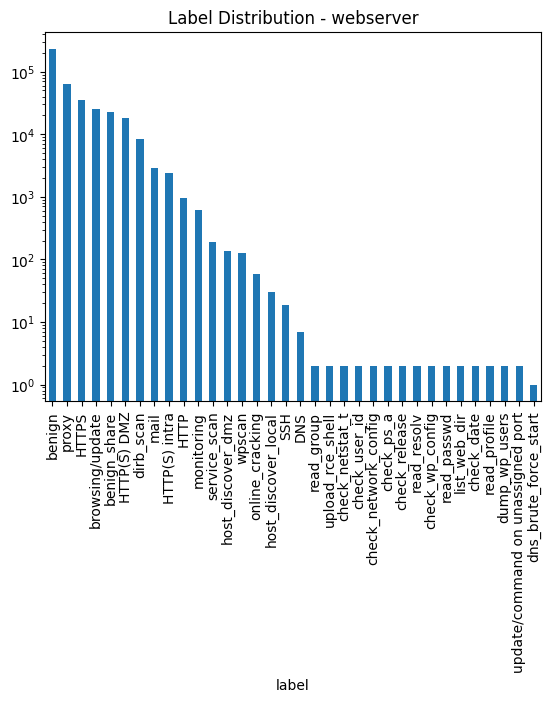

In [189]:
label_stats(df_all_sensors, sensor_host)

In [ ]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [190]:
dataset_stats(df_all_sensors)

Total Flows: 415317
Unique Source IPs: 119
Unique Destination IPs: 11716
Unique Source Ports: 46889
Unique Destination Ports: 2410


{'total_flows': 415317,
 'unique_src_ips': 119,
 'unique_dst_ips': 11716,
 'unique_src_ports': 46889,
 'unique_dst_ports': 2410}

In [ ]:
def dataset_stats_detailed(df, print_details=True):

    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

In [191]:
dataset_stats_detailed(df_all_sensors)

Total Flows: 415317

 --- IP distribution ---

Source IPs (119):
src_ip
172.17.130.196     118586
172.17.130.37       83735
192.168.128.4       83366
172.17.129.140      27222
10.35.33.111        26414
                    ...  
192.168.255.254         9
10.35.32.78             4
192.168.130.19          3
35.185.15.143           3
78.41.115.114           2
Name: count, Length: 119, dtype: int64

Destination IPs (11716):
dst_ip
172.17.130.37      62271
172.17.131.81      49348
192.168.255.254    48968
172.17.129.140     36505
172.17.128.1       29758
                   ...  
44.236.160.188         1
3.124.111.31           1
192.237.143.72         1
18.158.188.123         1
142.250.13.157         1
Name: count, Length: 11716, dtype: int64

 --- Port distribution ---
Source Ports (46889):
sport
133      16850
5353      5852
123       5825
138       4192
137       3298
         ...  
5912         1
10748        1
8795         1
15559        1
26881        1
Name: count, Length: 46889, dtype

(src_ip
 172.17.130.196     118586
 172.17.130.37       83735
 192.168.128.4       83366
 172.17.129.140      27222
 10.35.33.111        26414
                     ...  
 192.168.255.254         9
 10.35.32.78             4
 192.168.130.19          3
 35.185.15.143           3
 78.41.115.114           2
 Name: count, Length: 119, dtype: int64,
 dst_ip
 172.17.130.37      62271
 172.17.131.81      49348
 192.168.255.254    48968
 172.17.129.140     36505
 172.17.128.1       29758
                    ...  
 44.236.160.188         1
 3.124.111.31           1
 192.237.143.72         1
 18.158.188.123         1
 142.250.13.157         1
 Name: count, Length: 11716, dtype: int64,
 sport
 133      16850
 5353      5852
 123       5825
 138       4192
 137       3298
          ...  
 5912         1
 10748        1
 8795         1
 15559        1
 26881        1
 Name: count, Length: 46889, dtype: int64,
 dport
 443      210570
 53        95956
 445       25964
 80        21633
 134       16850